In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../Data/Polutan/CO_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['CO'] = pd.to_numeric(df['CO'], errors='coerce')

# Hitung IQR
Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

print("Jumlah Outlier CO (IQR):", len(outliers_iqr))

Jumlah Outlier CO (IQR): 6


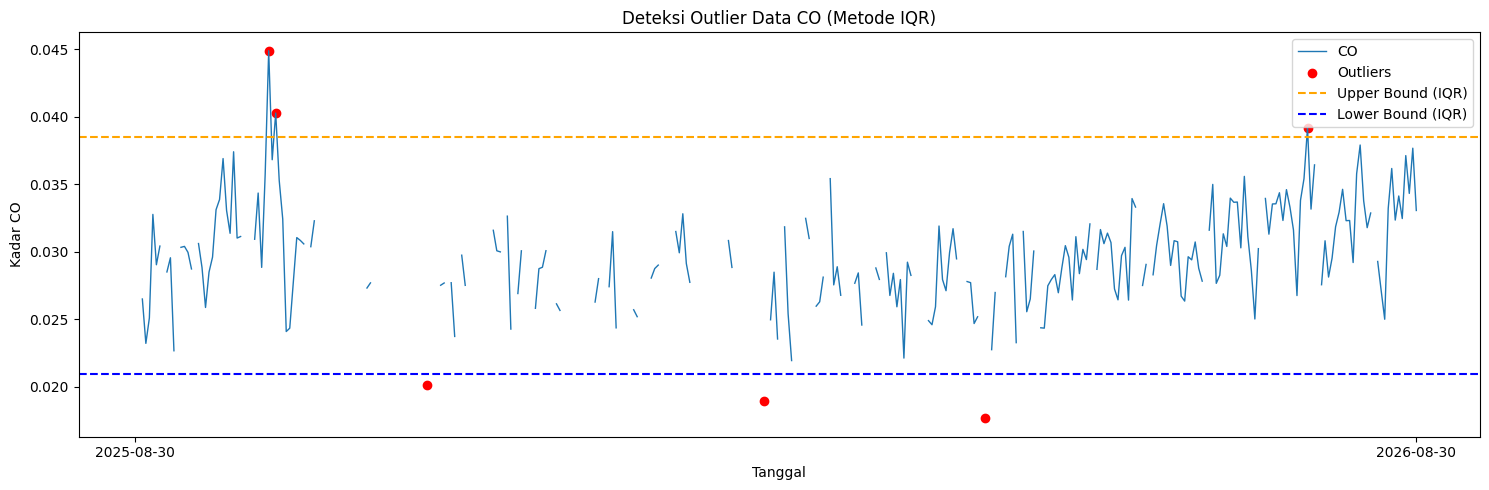

In [2]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['CO'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [3]:
df['CO_filled'] = df['CO'].copy()

# Looping iteratif untuk membersihkan outlier sampai benar-benar habis
while True:
    # 1. Hitung ulang kuartil dan batas IQR berdasarkan data saat ini
    Q1 = df['CO_filled'].quantile(0.25)
    Q3 = df['CO_filled'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 2. Deteksi lokasi outlier
    outliers = (df['CO_filled'] < lower_bound) | (df['CO_filled'] > upper_bound)
    
    # Jika sudah tidak ada outlier yang terdeteksi, hentikan perulangan
    if not outliers.any():
        break
    
    # 3. Mask nilai outlier menjadi NaN, lalu isi dengan interpolasi polinomial + bfill + ffill
    df['CO_filled'] = df['CO_filled'].mask(outliers)
    df['CO_filled'] = df['CO_filled'].interpolate(method='polynomial', order=1).bfill().ffill()

# 4. Simpan hasil akhir ke DataFrame baru dan ekspor ke CSV
df_co = pd.DataFrame({"date": df['date'], "CO": df['CO_filled']})
df_co.to_csv("../../Data/Polutan/CO_Filled_Polynomial.csv", index=False)
print("Data CO berhasil diproses dan disimpan ke CO_Filled_Polynomial.csv")

Data CO berhasil diproses dan disimpan ke CO_Filled_Polynomial.csv


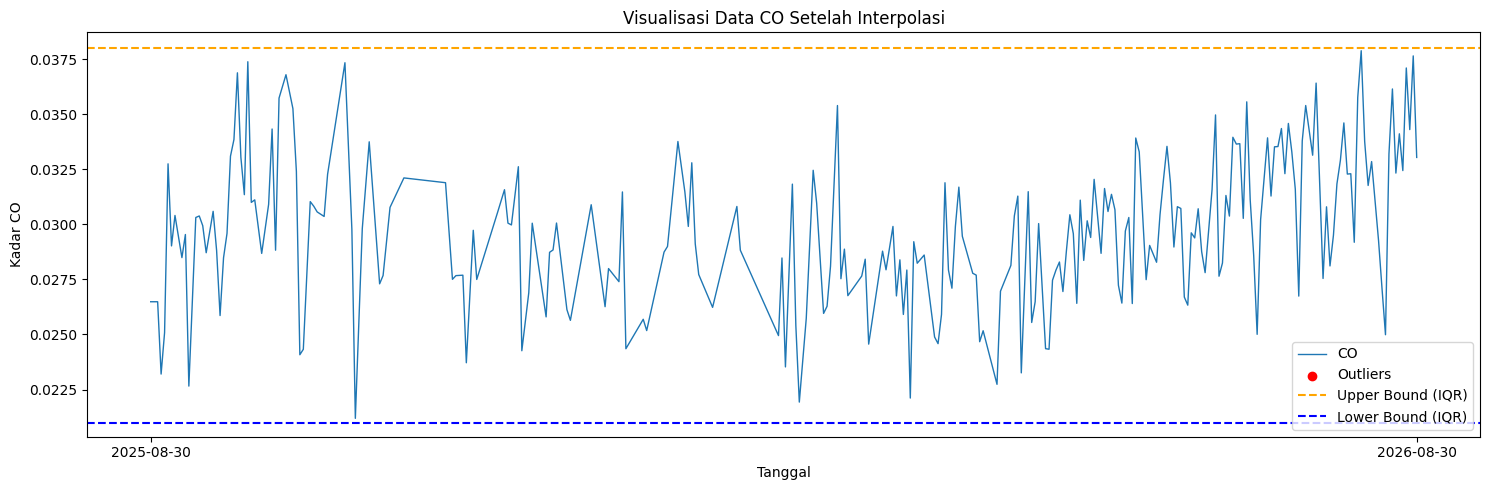

In [4]:
df_co_final = pd.read_csv("../../Data/Polutan/CO_Filled_Polynomial.csv")
df_co_final['date'] = pd.to_datetime(df_co_final['date'])

Q1 = df_co_final['CO'].quantile(0.25)
Q3 = df_co_final['CO'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_co_final[(df_co_final['CO'] < lower_bound) | (df_co_final['CO'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df_co_final['date'], df_co_final['CO'], label="CO", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['CO'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Visualisasi Data CO Setelah Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_co_final['date'].iloc[0], df_co_final['date'].iloc[-1]],
    labels=[df_co_final['date'].iloc[0].strftime('%Y-%m-%d'),
            df_co_final['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../Data/Polutan/SO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['SO2'] = pd.to_numeric(df['SO2'], errors='coerce')

# Hitung IQR
Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

print("Jumlah Outlier SO2 (IQR):", len(outliers_iqr))

Jumlah Outlier SO2 (IQR): 17


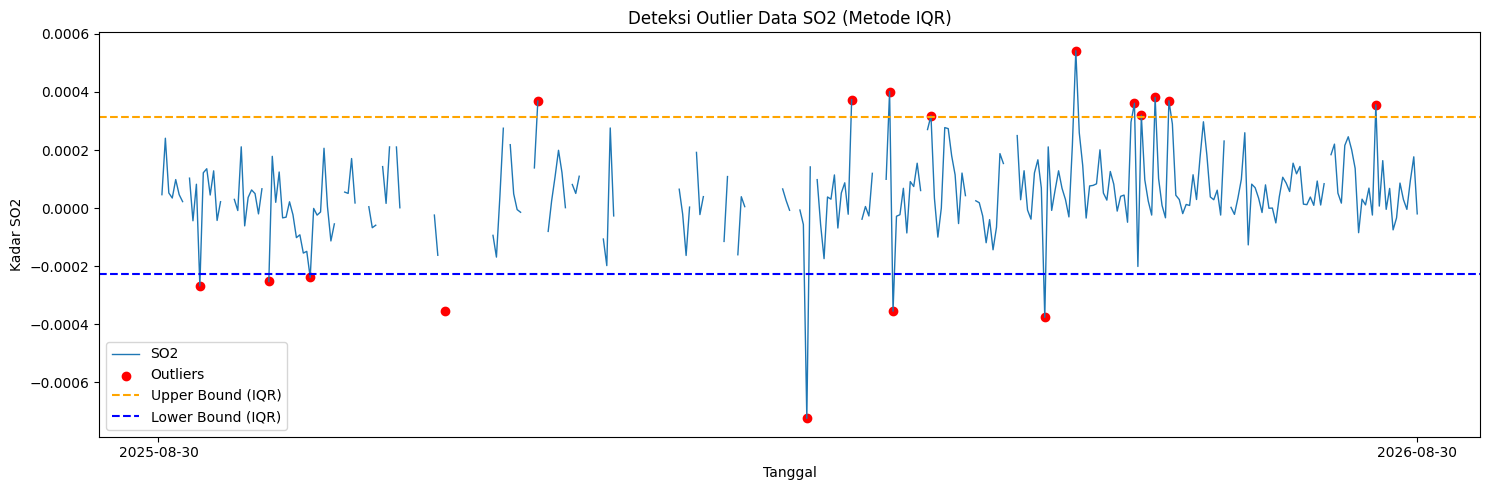

In [7]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [9]:
df['SO2_filled'] = df['SO2'].copy()

# Looping iteratif untuk membersihkan outlier sampai benar-benar habis
while True:
    # 1. Hitung ulang kuartil dan batas IQR berdasarkan data saat ini
    Q1 = df['SO2_filled'].quantile(0.25)
    Q3 = df['SO2_filled'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 2. Deteksi lokasi outlier
    outliers = (df['SO2_filled'] < lower_bound) | (df['SO2_filled'] > upper_bound)
    
    # Jika sudah tidak ada outlier yang terdeteksi, hentikan perulangan
    if not outliers.any():
        break
    
    # 3. Mask nilai outlier menjadi NaN, lalu isi dengan interpolasi polinomial + bfill + ffill
    df['SO2_filled'] = df['SO2_filled'].mask(outliers)
    df['SO2_filled'] = df['SO2_filled'].interpolate(method='polynomial', order=1).bfill().ffill()

# 4. Simpan hasil akhir ke DataFrame baru dan ekspor ke CSV
df_so2 = pd.DataFrame({"date": df['date'], "SO2": df['SO2_filled']})
df_so2.to_csv("../../Data/Polutan/SO2_Filled_Polynomial.csv", index=False)
print("Data SO2 berhasil diproses dan disimpan ke SO2_Filled_Polynomial.csv")

Data SO2 berhasil diproses dan disimpan ke SO2_Filled_Polynomial.csv


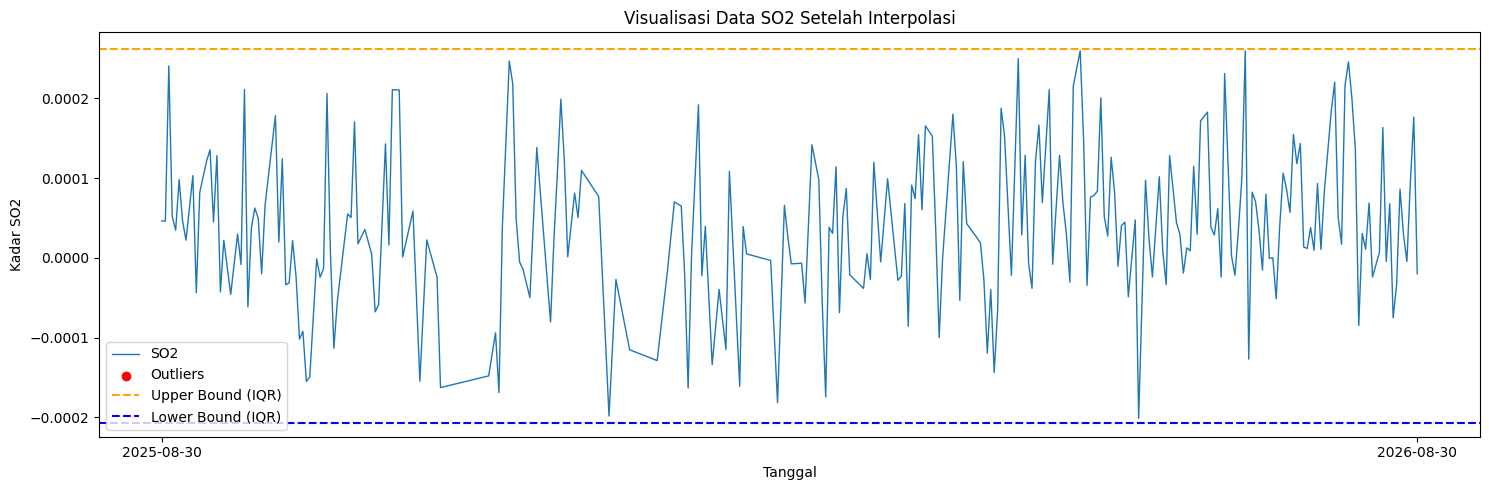

In [11]:
df_so2_final = pd.read_csv("../../Data/Polutan/SO2_Filled_Polynomial.csv")
df_so2_final['date'] = pd.to_datetime(df_so2_final['date'])

Q1 = df_so2_final['SO2'].quantile(0.25)
Q3 = df_so2_final['SO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_so2_final[(df_so2_final['SO2'] < lower_bound) | (df_so2_final['SO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df_so2_final['date'], df_so2_final['SO2'], label="SO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Visualisasi Data SO2 Setelah Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_so2_final['date'].iloc[0], df_so2_final['date'].iloc[-1]],
    labels=[df_so2_final['date'].iloc[0].strftime('%Y-%m-%d'),
            df_so2_final['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../Data/Polutan/NO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['NO2'] = pd.to_numeric(df['NO2'], errors='coerce')

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier NO2 (IQR):", len(outliers_iqr))

Jumlah Outlier NO2 (IQR): 2


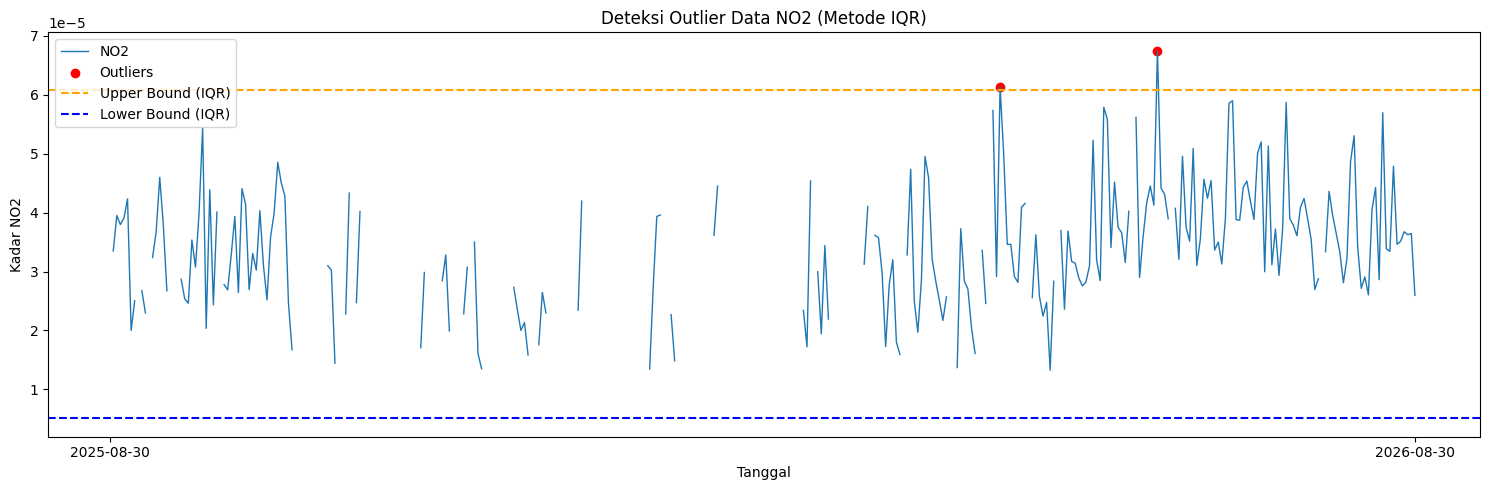

In [13]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [14]:
df['NO2_filled'] = df['NO2'].copy()

# Looping iteratif untuk membersihkan outlier sampai benar-benar habis
while True:
    # 1. Hitung ulang kuartil dan batas IQR berdasarkan data saat ini
    Q1 = df['NO2_filled'].quantile(0.25)
    Q3 = df['NO2_filled'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 2. Deteksi lokasi outlier
    outliers = (df['NO2_filled'] < lower_bound) | (df['NO2_filled'] > upper_bound)
    
    # Jika sudah tidak ada outlier yang terdeteksi, hentikan perulangan
    if not outliers.any():
        break
    
    # 3. Mask nilai outlier menjadi NaN, lalu isi dengan interpolasi polinomial + bfill + ffill
    df['NO2_filled'] = df['NO2_filled'].mask(outliers)
    df['NO2_filled'] = df['NO2_filled'].interpolate(method='polynomial', order=1).bfill().ffill()

# 4. Simpan hasil akhir ke DataFrame baru dan ekspor ke CSV
df_no2 = pd.DataFrame({"date": df['date'], "NO2": df['NO2_filled']})
df_no2.to_csv("../../Data/Polutan/NO2_Filled_Polynomial.csv", index=False)
print("Data NO2 berhasil diproses dan disimpan ke NO2_Filled_Polynomial.csv")

Data NO2 berhasil diproses dan disimpan ke NO2_Filled_Polynomial.csv


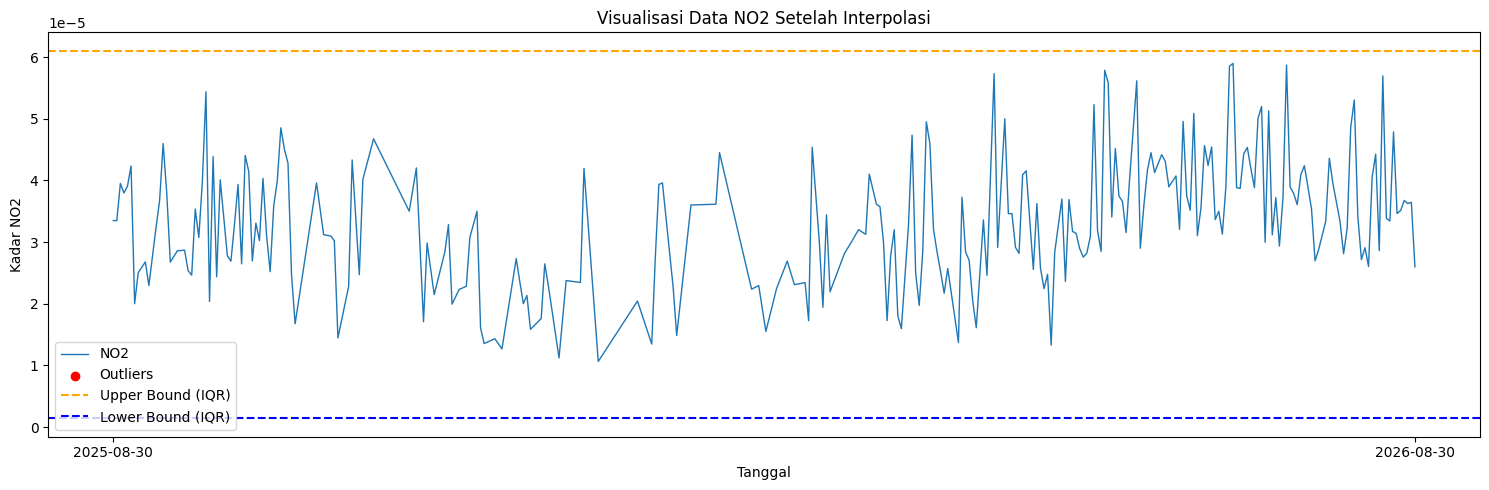

In [15]:
df_no2_final = pd.read_csv("../../Data/Polutan/NO2_Filled_Polynomial.csv")
df_no2_final['date'] = pd.to_datetime(df_no2_final['date'])

Q1 = df_no2_final['NO2'].quantile(0.25)
Q3 = df_no2_final['NO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_no2_final[(df_no2_final['NO2'] < lower_bound) | (df_no2_final['NO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df_no2_final['date'], df_no2_final['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Visualisasi Data NO2 Setelah Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_no2_final['date'].iloc[0], df_no2_final['date'].iloc[-1]],
    labels=[df_no2_final['date'].iloc[0].strftime('%Y-%m-%d'),
            df_no2_final['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

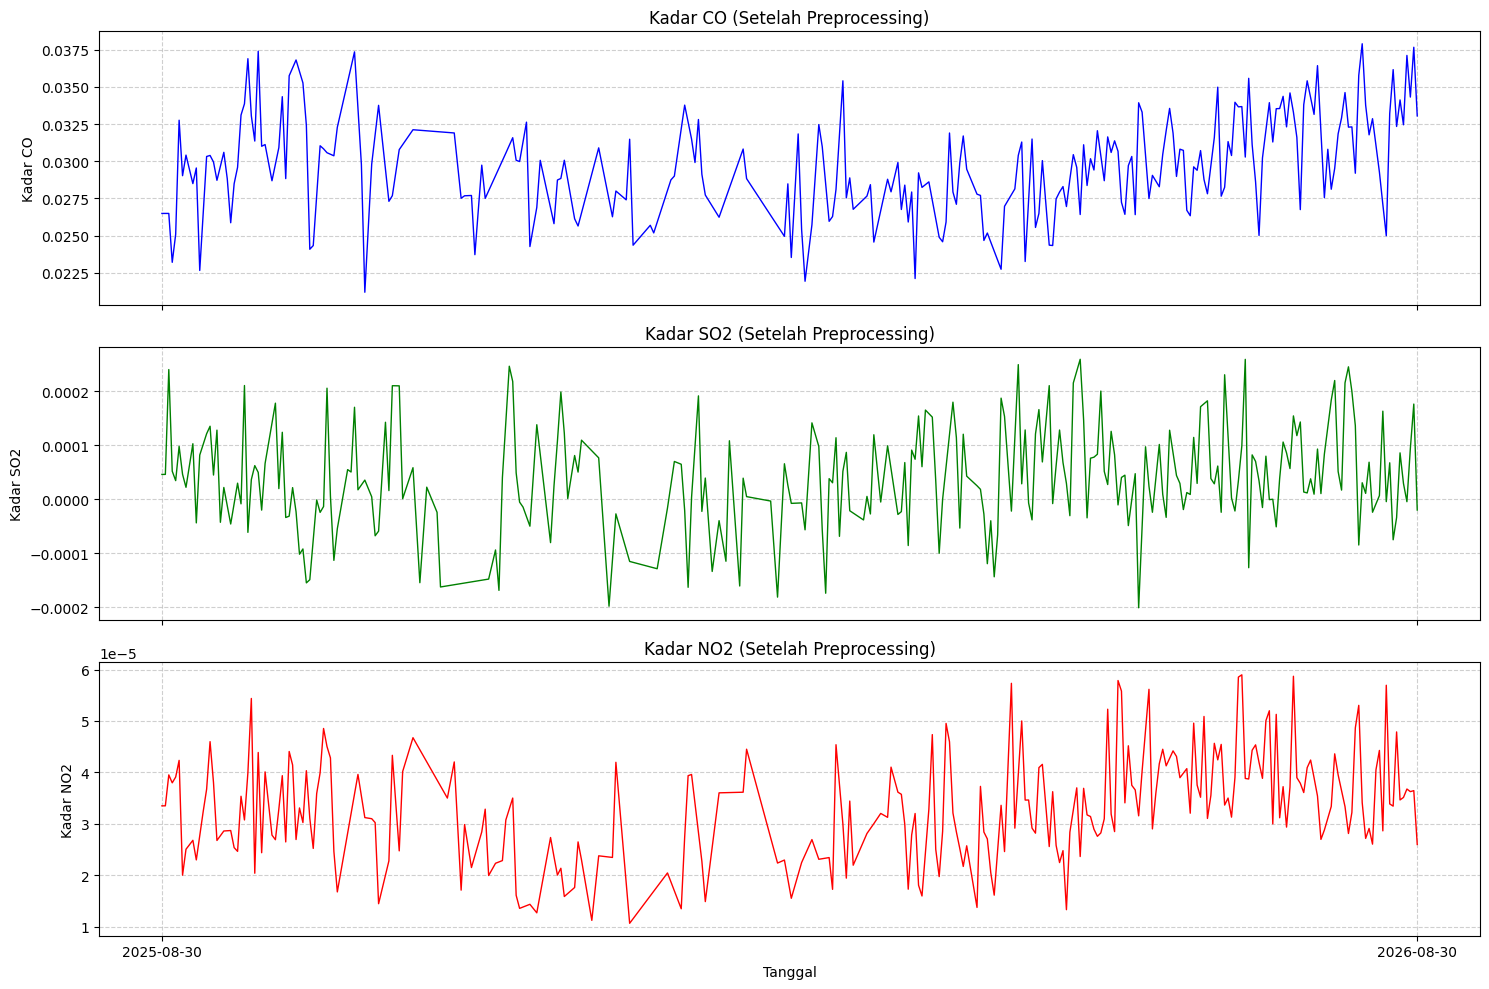

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Memuat data yang telah diproses
df_co = pd.read_csv("../../Data/Polutan/CO_Filled_Polynomial.csv")
df_so2 = pd.read_csv("../../Data/Polutan/SO2_Filled_Polynomial.csv")
df_no2 = pd.read_csv("../../Data/Polutan/NO2_Filled_Polynomial.csv")

df_co['date'] = pd.to_datetime(df_co['date'])
df_so2['date'] = pd.to_datetime(df_so2['date'])
df_no2['date'] = pd.to_datetime(df_no2['date'])

# Membuat subplot untuk ketiga polutan
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Plot CO
axes[0].plot(df_co['date'], df_co['CO'], color='blue', linewidth=1)
axes[0].set_title('Kadar CO (Setelah Preprocessing)')
axes[0].set_ylabel('Kadar CO')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot SO2
axes[1].plot(df_so2['date'], df_so2['SO2'], color='green', linewidth=1)
axes[1].set_title('Kadar SO2 (Setelah Preprocessing)')
axes[1].set_ylabel('Kadar SO2')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot NO2
axes[2].plot(df_no2['date'], df_no2['NO2'], color='red', linewidth=1)
axes[2].set_title('Kadar NO2 (Setelah Preprocessing)')
axes[2].set_xlabel('Tanggal')
axes[2].set_ylabel('Kadar NO2')
axes[2].grid(True, linestyle='--', alpha=0.6)

# Menyesuaikan tampilan sumbu X
plt.xticks(
    ticks=[df_co['date'].iloc[0], df_co['date'].iloc[-1]],
    labels=[df_co['date'].iloc[0].strftime('%Y-%m-%d'),
            df_co['date'].iloc[-1].strftime('%Y-%m-%d')]
)

plt.tight_layout()
plt.show()

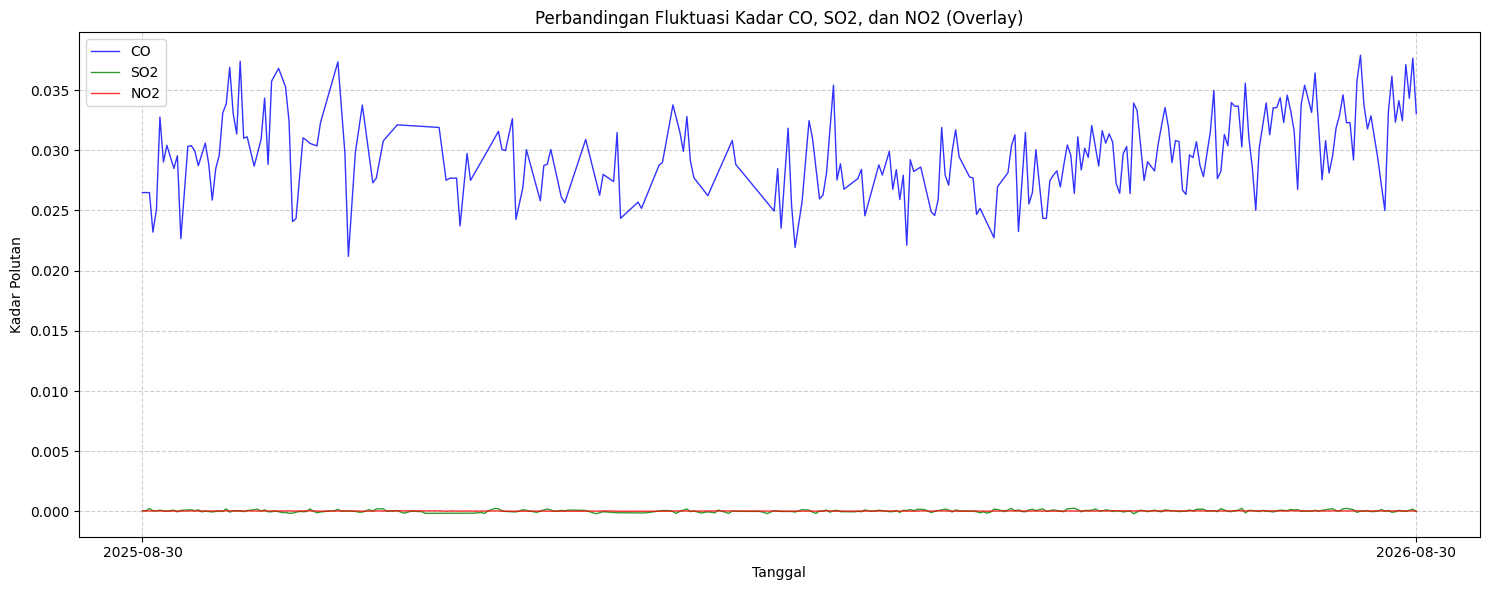

In [17]:
plt.figure(figsize=(15, 6))

# Plot ketiga polutan dalam satu axis
plt.plot(df_co['date'], df_co['CO'], color='blue', label='CO', linewidth=1, alpha=0.8)
plt.plot(df_so2['date'], df_so2['SO2'], color='green', label='SO2', linewidth=1, alpha=0.8)
plt.plot(df_no2['date'], df_no2['NO2'], color='red', label='NO2', linewidth=1, alpha=0.8)

plt.title('Perbandingan Fluktuasi Kadar CO, SO2, dan NO2 (Overlay)')
plt.xlabel('Tanggal')
plt.ylabel('Kadar Polutan')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Menyesuaikan tampilan sumbu X
plt.xticks(
    ticks=[df_co['date'].iloc[0], df_co['date'].iloc[-1]],
    labels=[df_co['date'].iloc[0].strftime('%Y-%m-%d'),
            df_co['date'].iloc[-1].strftime('%Y-%m-%d')]
)

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

# Memuat data yang telah diproses
df_co = pd.read_csv("../../Data/Polutan/CO_Filled_Polynomial.csv")
df_no2 = pd.read_csv("../../Data/Polutan/NO2_Filled_Polynomial.csv")
df_so2 = pd.read_csv("../../Data/Polutan/SO2_Filled_Polynomial.csv")

dataframe_merged = pd.DataFrame({
    "date": df_no2['date'],
    "CO": df_co['CO'],
    "NO2": df_no2['NO2'],
    "SO2": df_so2['SO2']
})

dataframe_merged.to_csv("../../Data/Polutan/Polutan_Widang_polynomial.csv", index=False)
print("Data polutan berhasil digabungkan dan disimpan ke Polutan_Widang_polynomial.csv")

Data polutan berhasil digabungkan dan disimpan ke Polutan_Widang_polynomial.csv


In [20]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat 1 file CSV utama yang berisi semua polutan ----------
df = pd.read_csv('../../Data/Polutan/Polutan_Widang_polynomial.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

pollutants = ['NO2', 'SO2', 'CO']
fs = 1

# ---------- 2. Daftar 68 Fitur TSFEL ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print(f"Jumlah fitur per polutan: {len(FEATURE_LIST)}")
print(f"Total target fitur keseluruhan: {len(FEATURE_LIST) * len(pollutants)}")

# ---------- 3. Fungsi ekstraksi dan penyeragaman output  ----------
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

# Dictionary untuk menampung seluruh hasil ekstraksi
combined_row = {}

# ---------- 4. Looping untuk membersihkan dan mengekstraksi tiap polutan ----------
for pollutant in pollutants:
    print(f"\n--- Memproses polutan: {pollutant} ---")
    
    df_poly = df[['date', pollutant]].copy()
    df_poly[pollutant] = pd.to_numeric(df_poly[pollutant], errors='coerce')

    # Handling outlier dengan IQR (sebagai safeguard tambahan)
    Q1 = df_poly[pollutant].quantile(0.25)
    Q3 = df_poly[pollutant].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_poly.loc[(df_poly[pollutant] < lower_bound) | (df_poly[pollutant] > upper_bound), pollutant] = np.nan

    # Interpolasi waktu dan cleaning
    df_clean = df_poly.set_index('date').interpolate(method='time').ffill().bfill()
    signal_1d = df_clean[pollutant].astype(float).values

    # Ekstraksi fitur dan beri prefix nama polutan (misal: NO2_abs_energy)
    for fn_name in FEATURE_LIST:
        feature_key = f"{pollutant}_{fn_name}"
        combined_row[feature_key] = extract_one(fn_name, signal_1d, fs)

# ---------- 5. Simpan ke DataFrame final ----------
extracted_features_final = pd.DataFrame([combined_row])
print(f"\nBerhasil! Total kolom akhir yang dihasilkan: {extracted_features_final.shape[1]}")

output_filename = '../../Data/Polutan/Widang_Polynomial.csv'
extracted_features_final.to_csv(output_filename, index=False)
print(f"File berhasil disimpan sebagai: {output_filename}")

Jumlah fitur per polutan: 68
Total target fitur keseluruhan: 204

--- Memproses polutan: NO2 ---

--- Memproses polutan: SO2 ---

--- Memproses polutan: CO ---

Berhasil! Total kolom akhir yang dihasilkan: 204
File berhasil disimpan sebagai: ../../Data/Polutan/Widang_Polynomial.csv
